# 1장 실습
----

In [22]:
import pandas as pd

df = pd.DataFrame(pd.read_csv('dataset.csv'))

artists_mode = df['artists'].mode()[0]
track_name_mode = df['track_name'].mode()[0]

df['artists'] = df['artists'].fillna(artists_mode)
df['track_name'] = df['track_name'].fillna(track_name_mode)

df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          1
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [37]:
df.duplicated().sum()

df.drop_duplicates().reset_index(drop=True)

df = df[(df['duration_ms'] > 0) & (df['duration_ms'] <= 1000000)]

df['duration_ms'].describe()

count     113884.000000
mean      226332.881011
std        86342.767586
min         8586.000000
25%       174026.000000
50%       212842.000000
75%       261303.750000
max      1000000.000000
Name: duration_ms, dtype: float64

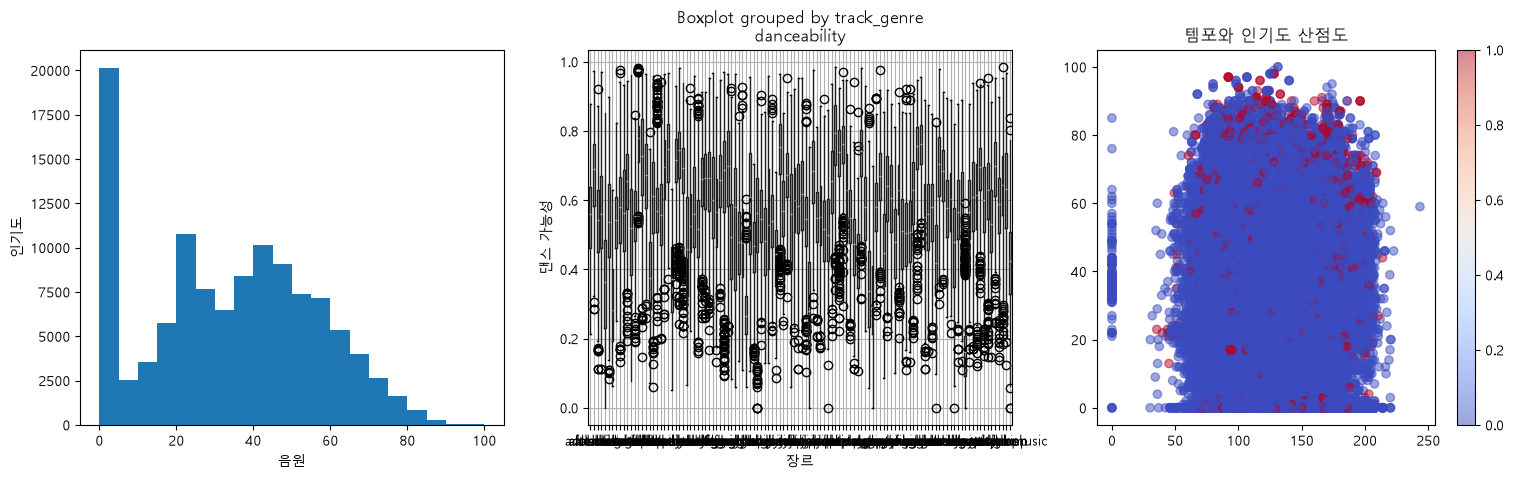

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import platform
from matplotlib import rc

os_name = platform.system()

if os_name == 'Windows':
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].hist(df['popularity'], bins=20)
axes[0].set_xlabel("음원")
axes[0].set_ylabel("인기도")

axes[1].set_title("장르별 댄스 가능성")
df_boxplt = df.boxplot(column='danceability', by='track_genre', ax=axes[1])
df_boxplt.set_ylabel("댄스 가능성")
df_boxplt.set_xlabel("장르")

scatter = plt.scatter(df['tempo'], df['popularity'], c=df['explicit'], alpha=0.5)
scatter.set_cmap("coolwarm")
axes[2].set_title("템포와 인기도 산점도")

fig.colorbar(scatter)

plt.show()